# Zadanie 2: optymalizacja z ograniczeniami

Termin realizacji: 30 marca 2026

Wybierz funkcję testową wykorzystaną w zadaniu 1.

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Dodaj ograniczenie postaci $x_1^2 + x_2 + b = 0$ ze stałą $b$ dopasowaną w taki sposób, aby żadne minimum lokalne (przynajmniej w zakresie w którym losowany jest punkt początkowy) nie spełniało ograniczenia.
2. Zaimplementuj metodę funkcji kary do rozwiązania tego problemu. Zwróć uwagę, aby metoda wykonywała częściową optymalizację dla każdej wielkości parametru kary $\mu_k$ (wykonanie od 1 do 5 kroków dla ustalonej wartości parametru kary -- do samodzielnego wyboru).
3. Wylosuj 10 punktów z dziedziny przeszukiwania z tabelki. Dla każdego z nich przeprowadź 100 kroków optymalizacji metodą największego spadku ze stałym krokiem. Narysuj wykres zależności wartości funkcji optymalizowanej od kroku optymalizacji.
4. Wykorzystaj ponownie metodę optymalizacji z poprzedniego projektu. Jako funkcję celu i jej gradient przekaż funkcje uwzględniające karę (ogólny schemat):
```
function penalty_gradient_descent(f, f_grad, x0; ...)
    x_k = copy(x0)
    for i in 1:max_iter
        # dodać: wyliczanie współczynnika kary
        function penalized_f(x)
            # do uzupełnienia
        end
        function penalized_f_grad(x)
            # do uzupełnienia
        end
        x_k = gradient_descent(penalized_f, penalized_f_grad, x_k; max_iter=3)
    end
end
```
5. Przeprowadź procedurę dla kilkunastu kroków. Spróbuj zilustrować brak zbieżności, szybką zbieżność i powolną zbieżność.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zamień metodę największego spadku na metodę gradientów sprzężonych. Metoda ta powinna wykorzystywać przeszukiwanie w kierunku uwzględniające regułę Armijo.
3. Wraz ze zwiększaniem się parametru kary powinna maleć norma gradientu przy której kończymy działanie metody gradientów sprzężonych, na przykład może być równa $10^{-2} / \mu_k$. 

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Wykonaj benchmarking metody z użyciem `BenchmarkTools.jl`. Zanotuj czasy działania wywołań optymalizacji oraz liczbę alokacji. Spróbuj zoptymalizować działanie funkcji korzystając wymienionych tu rad: [Julia performance tips](https://docs.julialang.org/en/v1/manual/performance-tips/). W sprawozdaniu napisz jakie zmiany wykonane i jak wpłynęły na czas działania programu.

Uwagi:

1. Dodanie typów w nagłówku metody przyspiesza kod tylko w rzadkich i bardzo szczególnych sytuacjach, i to tylko dla typów reprezentujących typy (`Core.Type`) lub funkcje.
2. Dobrym pomysłem jest wykonywanie operacji na tablicach w miejscu i unikanie alokacji. Warto też zwrócić uwagę na tzw. _type stability_, czyli unikanie sytuacji w których typ zmiennej zależy od wartości innej zmiennej.


## Funkcja: Three-hump camel function - z poprzedniego zadania
$f(x,y)=2x^{2}-1.05x^{4}+{\frac {x^{6}}{6}}+xy+y^{2}$

Ma globalne minimum w punkcie $(0, 0)$ z wartością $f(0,0) = 0$.

In [1]:
function f(x::Vector)
    return 2*x[1]^2 - 1.05*x[1]^4 + x[1]^6/6 + x[1]*x[2] + x[2]^2
end

# Gradient funkcji
function grad_f!(g::Vector, x::Vector)
    g[1] = 4*x[1] - 4.2*x[1]^3 + x[1]^5 + x[2]
    g[2] = x[1] + 2*x[2]
end

# Dziedzina: [-5, 5] x [-5, 5]
const DOMAIN = (-5.0, 5.0)

(-5.0, 5.0)

In [2]:
using LinearAlgebra
using Plots
using Random

In [3]:
# Losowanie 10 punktów z dziedziny DOMAIN × DOMAIN
Random.seed!(42)
function rand_uniform(a, b)
    return [rand() * (b - a) + a, rand() * (b - a) + a]
end

starting_points = [rand_uniform(DOMAIN[1], DOMAIN[2]) for _ in 1:10]
println("Wylosowane punkty startowe:")
for (i, p) in enumerate(starting_points)
    println("  $i: x = $(round.(p, digits=2))")
end

Wylosowane punkty startowe:
  1: x = [1.29, -0.5]
  2: x = [-0.23, 2.03]
  3: x = [1.73, -3.34]
  4: x = [1.13, 1.68]
  5: x = [-0.43, -2.01]
  6: x = [1.61, 1.39]
  7: x = [-1.57, -2.32]
  8: x = [0.16, -4.1]
  9: x = [-2.27, -3.08]
  10: x = [-0.76, -0.15]


In [4]:
function my_optimize_const_step(cost_data, grad_data, x0;
        step=1e-5, maxiter=100000, tol=1e-6)

    x = copy(x0)
    g = similar(x)

    fx = cost_data(x)
    if !isfinite(fx)
        error("cost_data(x0) is not finite (got $fx). Choose a valid x0 / fix 
                cost domain.")
    end

    for k in 1:maxiter
        grad_data(g, x)
        if any(!isfinite, g)
            error("Gradient became non-finite at iter=$k")
        end

        # Jeśli sie przesuwany o bardzo mały gradient 
        if norm(g) < tol
            return x
        end

        x .= x .- step .* g
    end
    # println("Exceeded maxiter=$maxiter without convergence")
    return x
end

# zapisywanie historii punktów
function optimize_with_history(cost, grad!, x0; step=0.01, maxiter=100, tol=1e-6, 
            optimization_function=my_optimize_const_step)
    x = copy(x0)
    history = Float64[]
    for k in 1:maxiter
        #push!(history, cost(x))
        x = optimization_function(cost, grad!, x; step=step, maxiter=1, tol=tol)
        push!(history, cost(x))
    end
    #push!(history, cost(x))
    return x, history
end

optimize_with_history (generic function with 1 method)

100 kroków optymalizacji dla każdego punktu - metoda ze stałym krokiem z zadania 1.

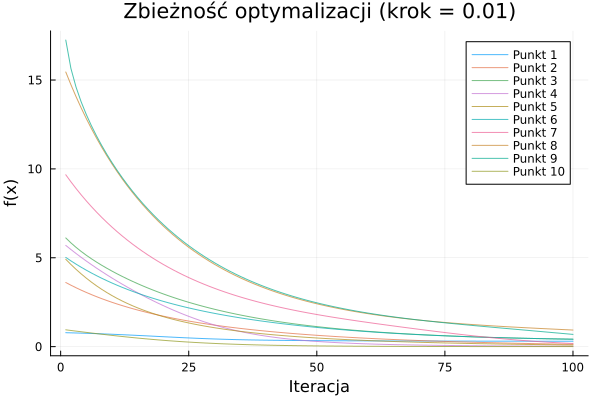

In [5]:
step_size = 0.01
all_histories = []

for x0 in starting_points
    _, hist = optimize_with_history(f, grad_f!, x0, step=step_size, maxiter=100)
    push!(all_histories, hist)
end

# Wykres
p = plot(title="Zbieżność optymalizacji (krok = $step_size)", 
         xlabel="Iteracja", ylabel="f(x)", legend=:topright)
for (i, hist) in enumerate(all_histories)
    plot!(p,  hist, label="Punkt $i", alpha=0.7)
end
display(p)

#### Wprowadzenie nowych elementów

Dodanie ograniczenia postaci $x_1^2 + x_2 + b = 0$. Zgodnie z poleceniem "stałą $b$ dopasowaną w taki sposób, aby żadne minimum lokalne (przynajmniej w zakresie w którym losowany jest punkt początkowy) nie spełniało ograniczenia."  
U nas minimum globale funkcji w punkcie f(0, 0) = 0.  

Stąd dobieramy b = 2.0

Zdefiniowanie funkcji oraz jej gradientu

In [6]:
const b = 2.0

function g(x)
    return x[1]^2 + x[2] + b
end

function grad_g(x)
    return [2*x[1], 1.0]
end

grad_g (generic function with 1 method)

In [7]:
function optimize_with_double_history(cost, grad!, x0;
        step=0.01, maxiter=100, tol=1e-6,
        optimization_function=my_optimize_const_step)

    x = copy(x0)

    x_history = Vector{Vector{Float64}}()
    cost_history = Float64[]

    for k in 1:maxiter
        x = optimization_function(cost, grad!, x;
                                 step=step, maxiter=1, tol=tol)

        push!(x_history, copy(x))
        push!(cost_history, cost(x))
    end

    return x, x_history, cost_history
end

function penalty_gradient_descent_double(f, grad_f!, x0;
        μ0 = 1.0, β = 1.3, max_iter = 15, iter = 5, step = 0.01)

    x_k = copy(x0)
    μ = μ0
    penalty_history = Float64[]
    original_history = Float64[]

    for i in 1:max_iter
        function penalized_f(x)
            return f(x) + μ * g(x)^2
        end
        function penalized_f_grad!(g_out, x)
            grad_f!(g_out, x)
            gx = g(x)
            gg = grad_g(x)
            g_out .+= 2 * μ * gx .* gg
        end

        effective_step = step / sqrt(μ)   # ← scale step down as μ grows

        x_k, x_hist, pen_hist = optimize_with_double_history(
            penalized_f, penalized_f_grad!, x_k;
            step = effective_step, maxiter = iter)

        append!(penalty_history, pen_hist)
        for x_val in x_hist
            push!(original_history, f(x_val))
        end

        μ *= β
    end

    return x_k, penalty_history, original_history
end

penalty_gradient_descent_double (generic function with 1 method)

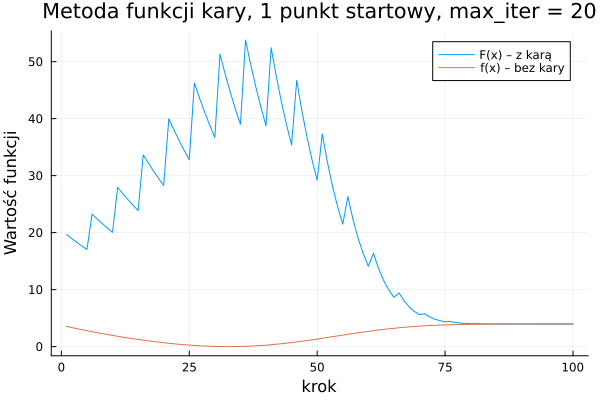

In [8]:
MAXITER = 20
p0 = starting_points[2]

x_opt, pen_hist, orig_hist = penalty_gradient_descent_double(
    f, grad_f!, p0; μ0=1.0, β=1.5, max_iter=MAXITER, iter=5, step=0.005)

plot(pen_hist, label="F(x) – z karą", xlabel="krok", ylabel="Wartość funkcji", title="Metoda funkcji kary, 1 punkt startowy, max_iter = $MAXITER")
plot!(orig_hist, label="f(x) – bez kary")

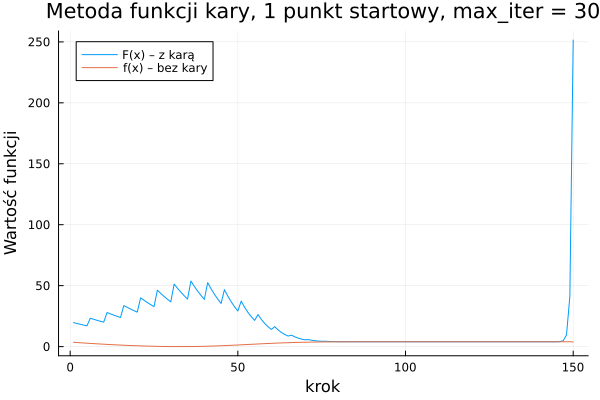

In [9]:
MAXITER = 30

x_opt, pen_hist, orig_hist = penalty_gradient_descent_double(
    f, grad_f!, p0; μ0=1.0, β=1.5, max_iter=MAXITER, iter=5, step=0.005)

plot(pen_hist, label="F(x) – z karą", xlabel="krok", ylabel="Wartość funkcji", title="Metoda funkcji kary, 1 punkt startowy, max_iter = $MAXITER")
plot!(orig_hist, label="f(x) – bez kary")

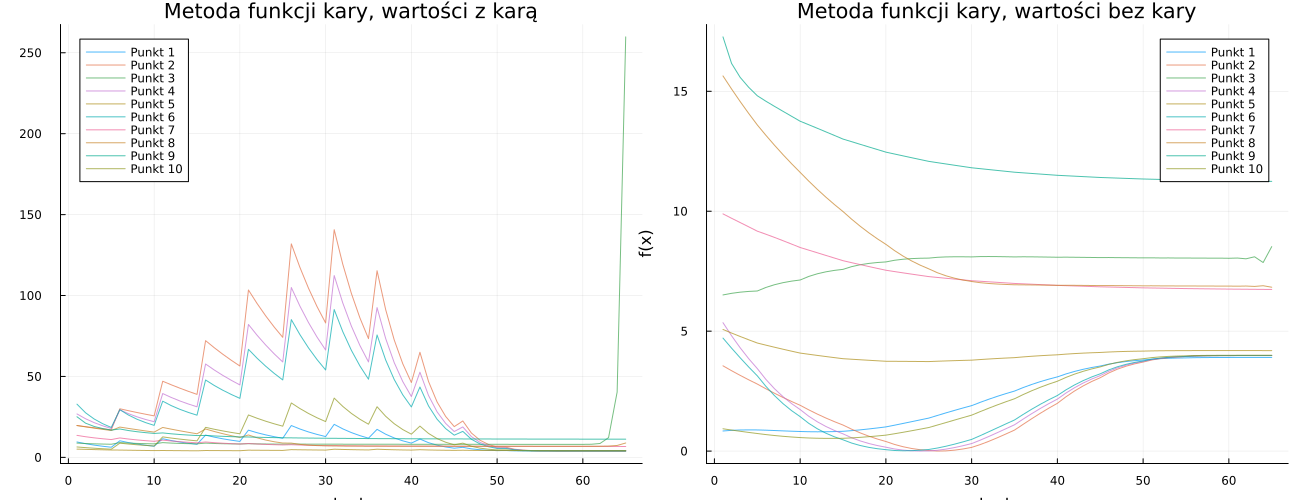

In [10]:
MAXITER = 13

p_penalty = plot(xlabel="krok", ylabel="F(x)", title="Metoda funkcji kary, wartości z karą")
p_orginial = plot(xlabel="krok", ylabel="f(x)", title="Metoda funkcji kary, wartości bez kary")

for x0 in starting_points
    # println("Optymalizacja dla punktu startowego: $(round.(x0, digits=2))")
    _, pen_hist, orig_hist = penalty_gradient_descent_double(f, grad_f!, x0; μ0=1.0, β=2.0, max_iter=MAXITER, iter=5, step=0.005)
    plot!(p_penalty, pen_hist, label="Punkt $(findfirst(==(x0), starting_points))", alpha=0.7)
    plot!(p_orginial, orig_hist, label="Punkt $(findfirst(==(x0), starting_points))", alpha=0.7)
end

plot([p_penalty, p_orginial]..., layout=(1, 2), size=(1300, 500))

### Obserwacje:

Wartości funkcji kosztu z wliczoną karą: 
- na początku obserwujemy wachania/skoki wartości funkcji kosztu, 
- następnie wartości maleją zbiżając się do zera,
- po większej ilości iteracji, rosną wykładniczo.

Z ilustrowano to wtraźnie na wykresach "Metoda funkcji kary, 1 punkt startowy, max_iter = 20" (wstępne skoki, powolne zbiżanie się do 0) oraz "Metoda funkcji kary, 1 punkt startowy, max_iter = 30" (wystrzał wartości z wliczonym kosztem do nieskończoności).

Wartości funkcji kosztu bez wliczonej kary wypłaszają się na tym samym poziomie co z wliczoną karą, jednak nie uciekają do nieskończoności.

Początkowe wahania funkcji kosztu z wliczoną karą wynikają ze zwiększania parametru μ.

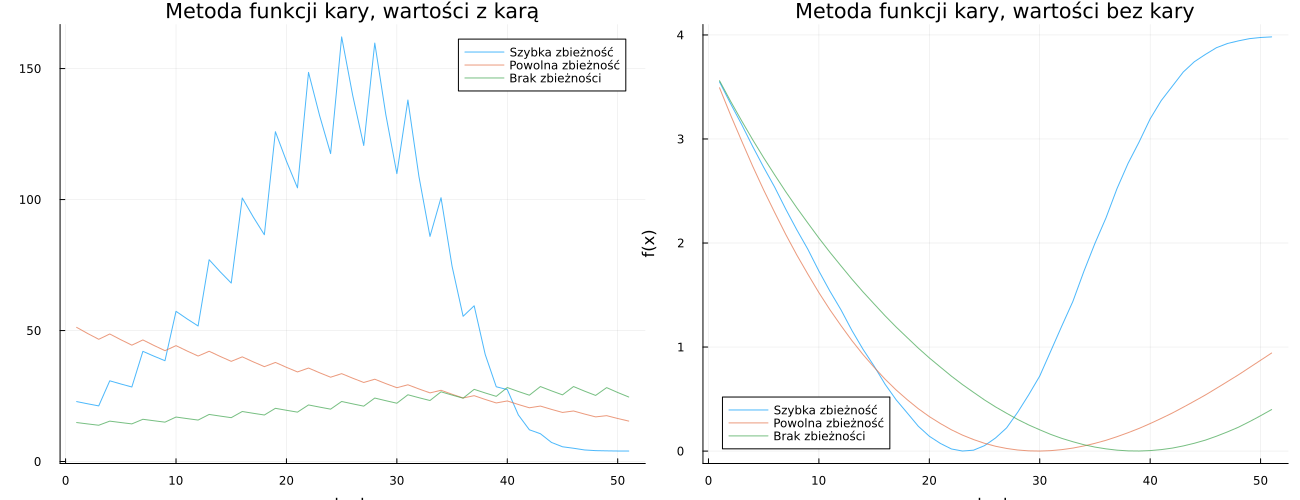

In [11]:
p0 = starting_points[2]
MAXITER = 17

_, h1p, h1o = penalty_gradient_descent_double(f, grad_f!, p0; μ0=1.2, β=1.6, max_iter=MAXITER, iter=3, step=0.005)
_, h2p, h2o = penalty_gradient_descent_double(f, grad_f!, p0; μ0=3.0, β=1.1, max_iter=MAXITER, iter=3, step=0.005)
_, h3p, h3o = penalty_gradient_descent_double(f, grad_f!, p0; μ0=0.7, β=1.2, max_iter=MAXITER, iter=3, step=0.005)

p_pen = plot(xlabel="krok", ylabel="F(x)", title="Metoda funkcji kary, wartości z karą")
p_org = plot(xlabel="krok", ylabel="f(x)", title="Metoda funkcji kary, wartości bez kary")

plot!(p_pen,  h1p, label="Szybka zbieżność", alpha=0.7)
plot!(p_pen,  h2p, label="Powolna zbieżność", alpha=0.7)
plot!(p_pen,  h3p, label="Brak zbieżności", alpha=0.7)

plot!(p_org,  h1o, label="Szybka zbieżność", alpha=0.7)
plot!(p_org,  h2o, label="Powolna zbieżność", alpha=0.7)
plot!(p_org,  h3o, label="Brak zbieżności", alpha=0.7)

plot([p_pen, p_org]..., layout=(1, 2), size=(1300, 500))

### Różne prędkości zbieżności

Dobierając parametry μ0 oraz β uzyskano przykłady szybkiej, powolnej i braku zbieżności.

## Na 4.0

In [12]:
# Optymalizacja metodą z warunkiem Armijo i kierunkiem z CG
# Różnica wględem poprzednego zadania - przekazanie kierunku d do funkcji, zamiast wyniczania -g wewnątrz
function armijo_line_search(cost, x, g, d, x_tmp; c=0.1, rho=0.8) # dodane x_temp

    fx = cost(x)
    slope = dot(g, d)
    alpha = 1.0

    while true
        @. x_tmp = x .+ alpha .* d # dodanie @.

        if isfinite(cost(x_tmp)) && cost(x_tmp) <= fx + c * alpha * slope
            break
        end

        alpha *= rho
        alpha < 1e-16 && break
    end

    return alpha
end

function conjugate_gradient(cost, grad!, x0;
        maxiter=100, tol=1e-6, c=0.1, rho=0.8)
    len = length(x0) # dodanie
    x = copy(x0)
    g = zeros(len)
    grad!(g, x)
    x_tmp = zeros(len)
    d = zeros(len) # dodanie
    @. d = -g # dodanie @.
    g_new = zeros(len) # dodanie

    x_history    = Vector{Vector{Float64}}() # dla wizualizacji
    cost_history = Float64[]

    for k in 1:maxiter

        push!(cost_history, cost(x))
        push!(x_history,    copy(x)) # dla wizualizacji
        norm(g) < tol && break

        α = armijo_line_search(cost, x, g, d, x_tmp; c=c, rho=rho)

        @. x = x .+ α .* d # usunięcie x_new

        # g_new = zeros(len) usunięcie; alokujemy ją przed funkcją
        grad!(g_new, x)

        β = dot(g_new, g_new) / dot(g, g)

        @. d = -g_new .+ β .* d #dodanie @.

        # usunięcie x = x_new 
        g .= g_new 
    end

    return x, x_history, cost_history
end

conjugate_gradient (generic function with 1 method)

Wprowadzenie metody gradientu sprzężonego z dodatkiem penalty

In [13]:
function penalty_conjugate_gradient(f, grad_f!, x0;
        μ0=1.0, β=2.0, max_iter=10)

    x = copy(x0)
    μ = μ0

    penalty_history  = Float64[]
    original_history = Float64[] # dla wizualizacji

    function penalized_f(x, μ_par)
        return f(x) + μ_par * g(x)^2
    end

    function penalized_grad!(out, x, μ_par)

        grad_f!(out, x)
        gx = g(x)
        gg = grad_g(x)
        out .+= 2 * μ_par * gx .* gg
    end

    # zmiana: wcześniej funkcje penalized_f i penalized_grad były tworzone przy każdej iteracji pętli. 
    # Teraz są tworzone przed nią z parametrem μ_par i wywoływane w pętli

    for k in 1:max_iter
        tol = 1e-2 / μ
        current_f = (xt) -> penalized_f(xt, μ)
        current_grad! = (out, xt) -> penalized_grad!(out, xt, μ)
        x, x_hist, pen_hist = conjugate_gradient( current_f, current_grad!, x;
            tol = tol, maxiter = 50 )

        append!(penalty_history, pen_hist)
        for x_val in x_hist
            push!(original_history, f(x_val))
        end

        μ *= β
    end

    return x, penalty_history, original_history
end

penalty_conjugate_gradient (generic function with 1 method)

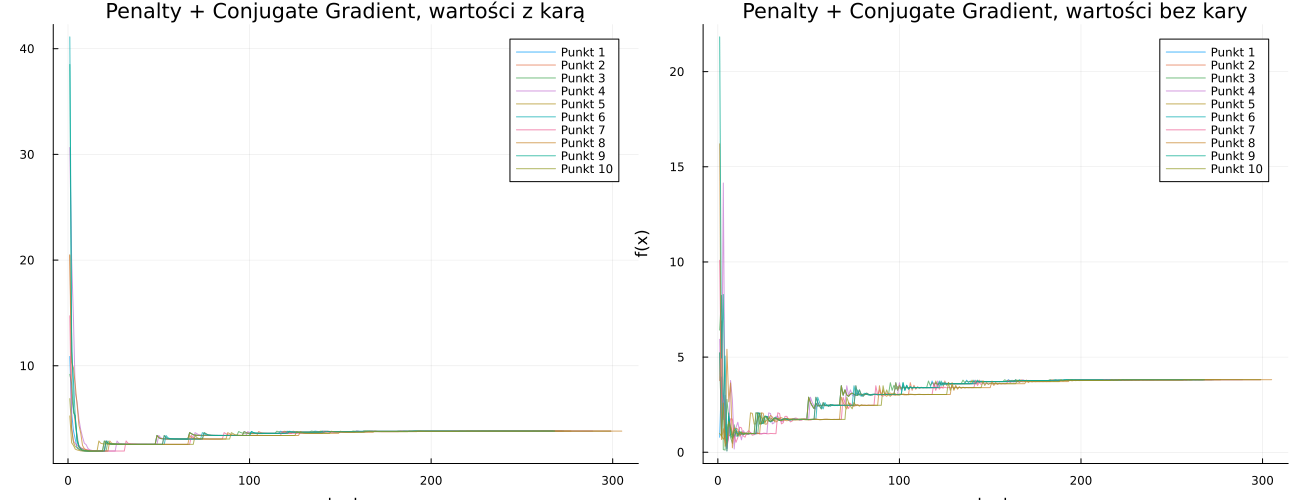

In [14]:
p_pen = plot(xlabel="krok", ylabel="F(x)", title="Penalty + Conjugate Gradient, wartości z karą")
p_org = plot(xlabel="krok", ylabel="f(x)", title="Penalty + Conjugate Gradient, wartości bez kary")

for x0 in starting_points
    _, pen_hist, orig_hist = penalty_conjugate_gradient(f, grad_f!, x0; μ0=1.0, β=2.0, max_iter=10)
    plot!(p_pen, pen_hist, label="Punkt $(findfirst(==(x0), starting_points))", alpha=0.7)
    plot!(p_org, orig_hist, label="Punkt $(findfirst(==(x0), starting_points))", alpha=0.7)
end

plot([p_pen, p_org]..., layout=(1, 2), size=(1300, 500))

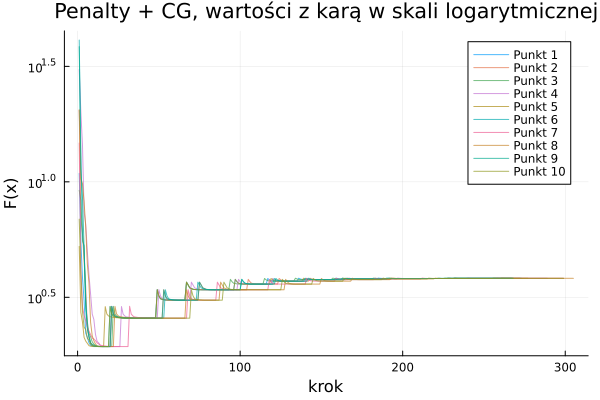

In [15]:
plot(p_pen, title="Penalty + CG, wartości z karą w skali logarytmicznej", yscale=:log10)

## Na 5.0

Finalny benchmark

In [16]:
using BenchmarkTools

x_0 = starting_points[1]

println("Final Benchmark")
benchmark = @btime penalty_conjugate_gradient(f, grad_f!, x_0)

Final Benchmark
  436.707 μs (20028 allocations: 368.23 KiB)


([0.17423603765199464, -2.0265702149674216], [10.881389781661747, 5.541287490379835, 3.856824844877778, 3.051713637798879, 2.212638792021187, 2.121520101307973, 2.005884755702831, 1.958318077656175, 1.9496935913415616, 1.9396065349256344  …  3.820985216513406, 3.8209852164899, 3.82098521648503, 3.82098521648308, 3.820985216481745, 3.8209852164805445, 3.820985216473895, 3.820985216471819, 3.8209852164712372, 3.8209852164710956], [0.7918379190967727, 3.953042589646854, 1.7146438340960037, 2.9895843090833156, 0.4553595291085768, 0.8513447695940974, 1.3179832975888575, 0.88515066599517, 0.8256905339466529, 1.0867240590383136  …  3.81363761011787, 3.8136389961068824, 3.81363832160193, 3.8136387223685695, 3.8136384040733144, 3.813638879706227, 3.813638162509305, 3.813638837799936, 3.8136385196019735, 3.8136386275481056])

Miejsca wszystkich zmian są opisane w komentarzach funkcji: armijo_line_search, conjugate_gradient, penalty_conjugate_gradient z części na 4.0. W tabelce poniżej przedstawione są zmiany dokonane w poszczególnych krokach, jak i zmiany w parametrach. Udało nam się zmniejszyć czas o ~ 34%, a liczbę alokacji o ~ 68 %.

| Lp | Czas | Liczba alokacja | rozmiar | zmiany |
|---|---|---|---|---|
|0.| 1.082 ms | 61435 | 1.23 MiB | kod początkowy |
|1.| 939.400 μs | 50185 | 822.15 KiB | <ul> <li> Alokacje wektorów - Zamieniono x .+ a*d na @. x += a*d </li> <li> Prealokacja - Bufor x_tmp stworzony raz przed pętlą </li> <li> Użycie makra @. (fusing) </li> </ul> |
|2.| 717.100 μs | 19683 | 336.97 KiB | Przekazywanie $\mu$ jako argumentu, zamiast tworzenie przy każdej pętli nowej funkcji |